# Lección 0 - Generar una base de datos

In [40]:
import pandas as pd
import numpy as np

# Configuración para reproducibilidad
np.random.seed(42)
n_rows = 1000

# Generación de variables independientes (Features)
data = {
    'Edad': np.random.randint(18, 70, n_rows),
    'Tiempo_Sitio_Minutos': np.random.uniform(5, 60, n_rows),
    'Sesiones_Mensuales': np.random.randint(1, 20, n_rows),
    'Dispositivo': np.random.choice(['Mobile', 'Desktop', 'Tablet'], n_rows),
    'Region': np.random.choice(['Norte', 'Sur', 'Centro', 'Este'], n_rows),
    'Suscrito_Newsletter': np.random.choice([0, 1], n_rows, p=[0.7, 0.3])
}

df = pd.DataFrame(data)

# Creación de la variable objetivo (Monto_Compra) con una relación matemática + ruido
# El gasto base es $50, influenciado por tiempo en sitio, sesiones y edad
df['Monto_Compra'] = (
    50 +
    (df['Tiempo_Sitio_Minutos'] * 1.5) +
    (df['Sesiones_Mensuales'] * 5) -
    (df['Edad'] * 0.2) +
    np.random.normal(0, 10, n_rows) # Ruido aleatorio para realismo
).clip(lower=20) # Asegurar un gasto mínimo de $20

# Guardar el archivo para usarlo en el proyecto
df.to_csv('ecommerce_data.csv', index=False)
print("Dataset 'ecommerce_data.csv' creado exitosamente con 1000 registros.")
df.head()

Dataset 'ecommerce_data.csv' creado exitosamente con 1000 registros.


,Edad,Tiempo_Sitio_Minutos,Sesiones_Mensuales,Dispositivo,Region,Suscrito_Newsletter,Monto_Compra
0,56,34.293950,19,Tablet,Centro,1,177.588124
1,69,18.335878,8,Tablet,Sur,1,79.728828
2,46,19.808378,5,Tablet,Este,1,100.015233
3,32,25.750629,8,Tablet,Este,1,124.419040
4,60,6.103916,12,Mobile,Este,1,102.829863


# Lección 1: Fundamentos del Aprendizaje de Máquina (en el texto) y todas las librerias que se usan

In [41]:
# import pandas as pd
# import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, accuracy_score, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingRegressor

import matplotlib.pyplot as plt
import seaborn as sns

# Lección 3: Preprocesamiento y escalamiento de datos

In [42]:
# --- Cargar el dataset ---
df = pd.read_csv('ecommerce_data.csv')

# --- Separar Variables Predictoras (X) y Objetivo (y) ---
X = df.drop('Monto_Compra', axis=1)
y = df['Monto_Compra']

# --- División del dataset (Evitar Data Leakage) ---
# Dividimos antes de procesar para que el escalador no "conozca" la media del test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Identificar tipos de columnas ---
cols_num = ['Edad', 'Tiempo_Sitio_Minutos', 'Sesiones_Mensuales']
cols_cat = ['Dispositivo', 'Region', 'Suscrito_Newsletter']

# --- Definir Transformaciones (Preprocessing) ---
# Para numéricas: Imputación por media + Estandarización (StandardScaler)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()) # Media 0 y Desv. Estándar 1
])

# Para categóricas: Imputación por moda + One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Crea columnas binarias
])

# --- Integrar todo en un ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, cols_num),
        ('cat', cat_transformer, cols_cat)
    ])

# --- Aplicar preprocesamiento ---
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Datos preprocesados con éxito.")
print(f"Forma original de X_train: {X_train.shape}")
print(f"Forma de X_train tras One-Hot Encoding: {X_train_prep.shape}")

Datos preprocesados con éxito.
Forma original de X_train: (800, 6)
Forma de X_train tras One-Hot Encoding: (800, 12)


# Lección 2: Nivel de ajuste del modelo y validación cruzada

In [43]:
# --- Entrenar el Modelo Base (Baseline) ---
model_base = LinearRegression()
model_base.fit(X_train_prep, y_train)

# --- Generar predicciones para comparar Train vs Test ---
y_train_pred = model_base.predict(X_train_prep)
y_test_pred = model_base.predict(X_test_prep)

# --- Calcular errores (Métricas de Ajuste) ---
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"MAE Entrenamiento: {mae_train:.2f}")
print(f"MAE Prueba: {mae_test:.2f}")

# --- Implementar Validación Cruzada (K-Fold con K=5) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_base, X_train_prep, y_train, cv=kf, scoring='r2')

print("-" * 30)
print(f"R² Promedio (Validación Cruzada): {cv_scores.mean():.4f}")
print(f"Variabilidad entre Folds (Std): {cv_scores.std():.4f}")

MAE Entrenamiento: 7.88
MAE Prueba: 8.04
------------------------------
R² Promedio (Validación Cruzada): 0.9281
Variabilidad entre Folds (Std): 0.0092


# Lección 4: Regresiones

--- Comparación de Modelos ---
Lineal     - MAE: 8.04 | R²: 0.9222
Polinomial - MAE: 8.30 | R²: 0.9183

--- Coeficientes del Modelo Lineal ---
                  Feature     Weight
2      Sesiones_Mensuales  27.926276
1    Tiempo_Sitio_Minutos  24.350381
5      Dispositivo_Tablet   0.919012
10  Suscrito_Newsletter_0   0.525369
6           Region_Centro   0.169784
9              Region_Sur   0.133626
7             Region_Este   0.091438
3     Dispositivo_Desktop  -0.349741
8            Region_Norte  -0.394848
11  Suscrito_Newsletter_1  -0.525369
4      Dispositivo_Mobile  -0.569271
0                    Edad  -2.517702


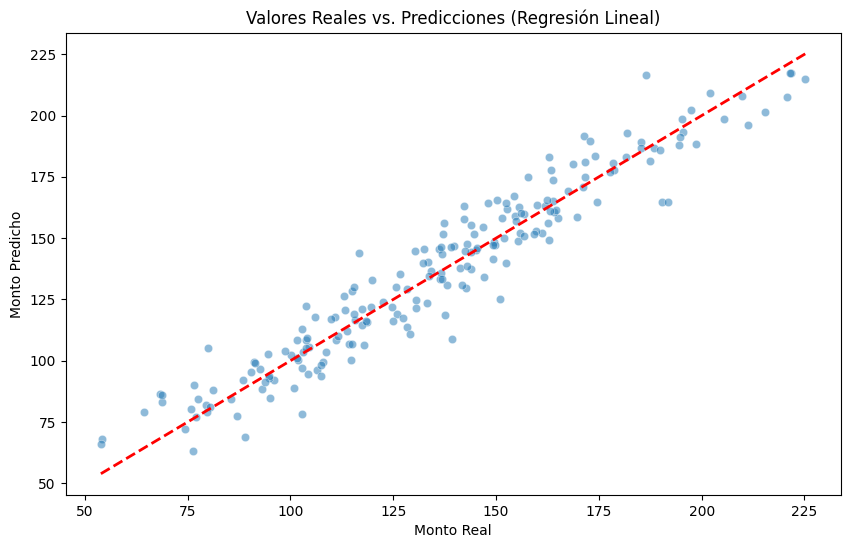

In [44]:
# --- Regresión Lineal ---
model_lin = LinearRegression()
model_lin.fit(X_train_prep, y_train)

# --- Regresión Polinomial (Grado 2) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_prep)
X_test_poly = poly.transform(X_test_prep)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# --- Comparación de Resultados ---
y_pred_lin = model_lin.predict(X_test_prep)
y_pred_poly = model_poly.predict(X_test_poly)

print("--- Comparación de Modelos ---")
print(f"Lineal     - MAE: {mean_absolute_error(y_test, y_pred_lin):.2f} | R²: {r2_score(y_test, y_pred_lin):.4f}")
print(f"Polinomial - MAE: {mean_absolute_error(y_test, y_pred_poly):.2f} | R²: {r2_score(y_test, y_pred_poly):.4f}")

# --- Interpretación de Coeficientes (Modelo Lineal) ---
# Obtenemos los nombres de las columnas tras el preprocesamiento
cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cols_cat)
feature_names = cols_num + list(cat_features)

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Weight': model_lin.coef_
}).sort_values(by='Weight', ascending=False)

print("\n--- Coeficientes del Modelo Lineal ---")
print(coefficients)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lin, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Valores Reales vs. Predicciones (Regresión Lineal)')
plt.xlabel('Monto Real')
plt.ylabel('Monto Predicho')
plt.savefig('reales_vs_predichos.png')
plt.show()

# Lección 5: Algoritmos de clasificación

In [45]:
# --- Transformar el Monto en Categorías (Bajo, Medio, Alto) ---
# Usamos qcut para dividir en 3 grupos con igual cantidad de datos
y_train_cat = pd.qcut(y_train, q=3, labels=['Bajo', 'Medio', 'Alto'])
y_test_cat = pd.qcut(y_test, q=3, labels=['Bajo', 'Medio', 'Alto'])

#  --- Implementar el Clasificador KNN ---
# Nota: KNN es muy sensible a la escala, pero ya escalamos X_train_prep en la Lección 3
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_prep, y_train_cat)

# --- Predicción y Evaluación ---
y_pred_knn = knn.predict(X_test_prep)

print("--- Evaluación del Clasificador KNN ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test_cat, y_pred_knn):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test_cat, y_pred_knn))

--- Evaluación del Clasificador KNN ---
Exactitud (Accuracy): 0.7150

Informe de Clasificación:
              precision    recall  f1-score   support

        Alto       0.77      0.79      0.78        67
        Bajo       0.74      0.88      0.80        67
       Medio       0.61      0.47      0.53        66

    accuracy                           0.71       200
   macro avg       0.70      0.71      0.70       200
weighted avg       0.70      0.71      0.70       200



# Lección 6: Métricas de desempeño

--- Tabla Comparativa de Desempeño ---
  Métrica  Regresión Lineal  Regresión Polinomial
0     MAE            8.0448                8.3037
1     MSE          106.1833              111.5552
2    RMSE           10.3045               10.5620
3      R²            0.9222                0.9183


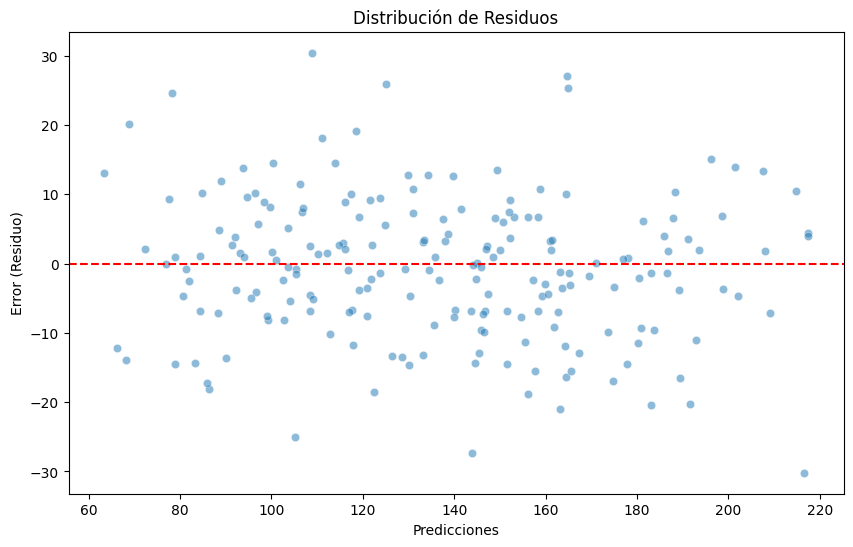

In [46]:
# --- Función para calcular el set completo de métricas ---
def obtener_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return mae, mse, rmse, r2

# --- Cálculo para ambos modelos ---
mae_l, mse_l, rmse_l, r2_l = obtener_metricas(y_test, y_pred_lin)
mae_p, mse_p, rmse_p, r2_p = obtener_metricas(y_test, y_pred_poly)

# --- Crear tabla comparativa ---
df_metrics = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Regresión Lineal': [mae_l, mse_l, rmse_l, r2_l],
    'Regresión Polinomial': [mae_p, mse_p, rmse_p, r2_p]
})

print("--- Tabla Comparativa de Desempeño ---")
print(df_metrics.round(4))

residuos = y_test - y_pred_lin

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lin, y=residuos, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Distribución de Residuos')
plt.xlabel('Predicciones')
plt.ylabel('Error (Residuo)')
plt.savefig('analisis_residuos.png')
plt.show()

# Lección 7: Optimización del modelo

In [47]:
# --- Ingeniería de Características (Feature Engineering) ---
# Creamos una variable de 'Interacción' que capture el engagement total del usuario
# Multiplicamos el tiempo por las sesiones para ver el impacto combinado
X_train_opt = X_train.copy()
X_test_opt = X_test.copy()

X_train_opt['Engagement_Total'] = X_train_opt['Tiempo_Sitio_Minutos'] * X_train_opt['Sesiones_Mensuales']
X_test_opt['Engagement_Total'] = X_test_opt['Tiempo_Sitio_Minutos'] * X_test_opt['Sesiones_Mensuales']

# Actualizamos los nombres de columnas para el preprocesador
cols_num_opt = cols_num + ['Engagement_Total']

# Volvemos a procesar con la nueva característica
preprocessor_opt = ColumnTransformer(
    transformers=[
        ('num', num_transformer, cols_num_opt),
        ('cat', cat_transformer, cols_cat)
    ])

X_train_final = preprocessor_opt.fit_transform(X_train_opt)
X_test_final = preprocessor_opt.transform(X_test_opt)

# --- Ajuste de Hiperparámetros con GridSearchCV (Ridge) ---
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(Ridge(), params, cv=5, scoring='neg_mean_absolute_error')
ridge_cv.fit(X_train_final, y_train)

# --- Aplicación de Lasso para Selección de Variables ---
lasso_cv = GridSearchCV(Lasso(), params, cv=5, scoring='neg_mean_absolute_error')
lasso_cv.fit(X_train_final, y_train)

# --- Comparación de Resultados ---
best_ridge = ridge_cv.best_estimator_
y_pred_opt = best_ridge.predict(X_test_final)

print(f"Mejor Alpha (Ridge): {ridge_cv.best_params_}")
print(f"MAE tras Optimización: {mean_absolute_error(y_test, y_pred_opt):.4f}")
print(f"R² tras Optimización: {r2_score(y_test, y_pred_opt):.4f}")

Mejor Alpha (Ridge): {'alpha': 0.01}
MAE tras Optimización: 8.1019
R² tras Optimización: 0.9216


# Lección 8: Algoritmos de Boosting

--- Duelo de Algoritmos ---
Modelo Lineal Optimizado (Ridge): MAE 8.1019 | R² 0.9216
Gradient Boosting Regressor:     MAE 8.2439 | R² 0.9167

--- Importancia de Variables (Boosting) ---
                Feature  Importance
3      Engagement_Total    0.902104
1  Tiempo_Sitio_Minutos    0.050499
2    Sesiones_Mensuales    0.038581
0                  Edad    0.006905
8           Region_Este    0.000461


/tmp/ipykernel_272/2574491545.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')


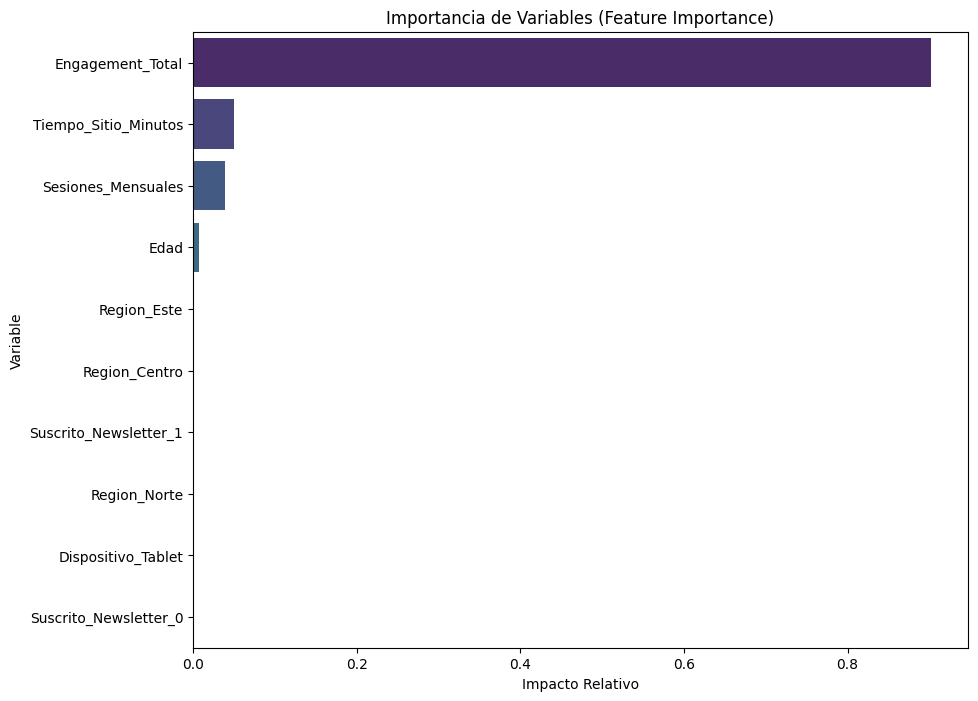

In [48]:
# --- Implementación de Gradient Boosting ---
# Usamos parámetros estándar: 100 árboles de profundidad 3
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gb.fit(X_train_final, y_train)

# --- Predicción y Evaluación ---
y_pred_gb = model_gb.predict(X_test_final)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# --- Comparativa Final Definitiva ---
print("--- Duelo de Algoritmos ---")
print(f"Modelo Lineal Optimizado (Ridge): MAE 8.1019 | R² 0.9216")
print(f"Gradient Boosting Regressor:     MAE {mae_gb:.4f} | R² {r2_gb:.4f}")

# --- Importancia de Variables (Feature Importance) ---
importances = pd.DataFrame({
    'Feature': cols_num_opt + list(cat_features),
    'Importance': model_gb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Importancia de Variables (Boosting) ---")
print(importances.head(5))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')
plt.title('Importancia de Variables (Feature Importance)')
plt.xlabel('Impacto Relativo')
plt.ylabel('Variable')
plt.savefig('importancia_variables.png')
plt.show()